# Churn Risk & MRR Forecasting Prototype

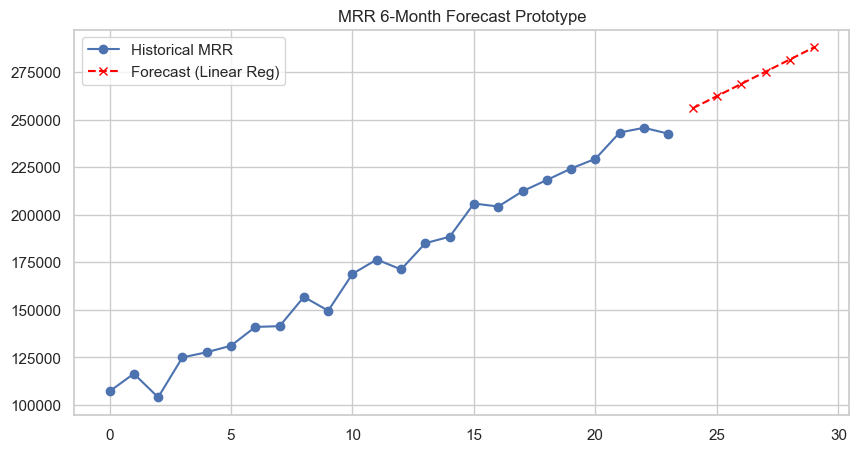

In [3]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Simulate loading historical MRR from our SQL Mart (core_mrr_movements)
# For prototyping, we use dummy monthly dates
dates = pd.date_range(start='2022-01-01', periods=24, freq='ME')
historical_mrr = np.linspace(100000, 250000, 24) + np.random.normal(0, 5000, 24)

df_mrr = pd.DataFrame({'month': dates, 'mrr': historical_mrr})
df_mrr['month_index'] = range(len(df_mrr))

# Fit Linear Regression for Trend
X = df_mrr[['month_index']]
y = df_mrr['mrr']
model = LinearRegression()
model.fit(X, y)

# Forecast next 6 months
future_indices = pd.DataFrame({'month_index': range(24, 30)})
forecast = model.predict(future_indices)

plt.figure(figsize=(10,5))
plt.plot(df_mrr['month_index'], df_mrr['mrr'], label='Historical MRR', marker='o')
plt.plot(future_indices['month_index'], forecast, label='Forecast (Linear Reg)', linestyle='--', color='red', marker='x')
plt.title("MRR 6-Month Forecast Prototype")
plt.legend()
plt.show()